IE-406 Machine Learning Lab-1

Student id= 202401034

Student Name= Shyam Bhuva


## ***Task 1: Dataset Preparation***

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing

1.


In [ ]:
data = fetch_california_housing()

x = data.data
y = data.target

print(x.shape)
print(y.shape)

(20640, 8)
(20640,)


2.

In [ ]:
np.random.seed(9432)

n = x.shape[0]

indices = np.random.permutation(n)

train_size = int(0.60 * n)
val_size = int(0.20 * n)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train = x[train_idx]
y_train = y[train_idx]

X_val = x[val_idx]
y_val = y[val_idx]

X_test = x[test_idx]
y_test = y[test_idx]

print("training")
print(X_train.shape)
print(y_train.shape)
print("\n")

print("validation")
print(X_val.shape)
print(y_val.shape)
print("\n")

print("test")
print(X_test.shape)
print(y_test.shape)
print("\n")

training
(12384, 8)
(12384,)


validation
(4128, 8)
(4128,)


test
(4128, 8)
(4128,)




3.

In [ ]:
# Feature normalization
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test = (X_test - X_mean) / X_std


# Target standardization
y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train = (y_train - y_mean) / y_std
y_val = (y_val - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

4.


In [ ]:
X_train = np.hstack((np.ones((X_train.shape[0], 1)), X_train))
X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

5. already done in step 4 of task 1


## ***Task 2: Implement Mini_Batch Gradint Descent***

In [ ]:
def mse(y_true, y_pred): #function created as it is used again ane agin
    return np.mean((y_true - y_pred) ** 2)

def train_model(X_train, y_train, X_val, y_val, learning_rate, batch_size):

    n_samples = X_train.shape[0]
    n_features = X_train.shape[1]

    # Initialize weights with zeros
    weights = np.zeros((n_features, 1))

    max_epochs = 1000
    patience = 100

    best_val_mse = float('inf')
    best_weights = weights.copy()
    best_epoch = 0

    train_losses = []
    val_losses = []

    epochs_without_improvement = 0

    for epoch in range(max_epochs):

        indices = np.random.permutation(n_samples)

        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        total_loss = 0
        total_samples = 0

        for start in range(0, n_samples, batch_size):

            end = min(start + batch_size, n_samples)

            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            current_batch_size = len(X_batch)

            y_pred = X_batch @ weights

            error = y_pred - y_batch.reshape(-1, 1)

            batch_mse = np.mean(error ** 2)

            gradient = (2 / current_batch_size) * (X_batch.T @ error)

            weights = weights - learning_rate * gradient

            total_loss += batch_mse * current_batch_size
            total_samples += current_batch_size

        epoch_train_mse = total_loss / total_samples

        y_val_pred = X_val @ weights

        epoch_val_mse = mse(
            y_val.reshape(-1, 1),
            y_val_pred
        )

        train_losses.append(epoch_train_mse)
        val_losses.append(epoch_val_mse)

        if epoch_val_mse < best_val_mse:

            best_val_mse = epoch_val_mse
            best_weights = weights.copy()
            best_epoch = epoch + 1

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return best_weights, train_losses, val_losses, best_epoch

learning_rate = 0.001
batch_size = 128

best_weights, train_losses, val_losses, best_epoch = train_model(
    X_train,
    y_train.reshape(-1, 1),
    X_val,
    y_val.reshape(-1, 1),
    learning_rate,
    batch_size
)

print("Best epoch:", best_epoch)
print("Best validation MSE:", min(val_losses))

Best epoch: 293
Best validation MSE: 0.3916782667777206


## ***Task 3: Effect of Learning Rate***

In [ ]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
batch_size = 128

results = {}

for lr in learning_rates:

    print("Training with learning rate:", lr)

    best_weights, train_losses, val_losses, best_epoch = train_model(
        X_train,
        y_train.reshape(-1, 1),
        X_val,
        y_val.reshape(-1, 1),
        learning_rate=lr,
        batch_size=batch_size
    )

    results[lr] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch
    }

for lr in learning_rates:

    best_val_mse = min(results[lr]["val_losses"])

    print(
        "Learning rate:",
        lr,
        "Best validation MSE:",
        best_val_mse,
        "Best epoch:",
        results[lr]["best_epoch"]
    )

    best_lr = min(
    learning_rates,
    key=lambda lr: min(results[lr]["val_losses"])
)

print("Best learning rate:", best_lr)


Training with learning rate: 1e-05
Training with learning rate: 0.0001
Training with learning rate: 0.001
Training with learning rate: 0.01
Training with learning rate: 0.1


/tmp/ipykernel_3654/1181868508.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_3654/1181868508.py:47: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error ** 2)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_3654/1181868508.py:49: RuntimeWarning: overflow encountered in matmul
  gradient = (2 / current_batch_size) * (X_batch.T @ error)
/tmp/ipykernel_3654/1181868508.py:43: RuntimeWarning: invalid value encountered in matmul
  y_pred = X_batch @ weights
/tmp/ipykernel_3654/1181868508.py:49: RuntimeWarning: invalid value encountered in matmul
  gradient = (2 / current_batch_size) * (X_batch.T @ error)


Training with learning rate: 1
Training with learning rate: 10
Learning rate: 1e-05 Best validation MSE: 0.47149194234807135 Best epoch: 1000
Learning rate: 0.0001 Best validation MSE: 0.3968411155139817 Best epoch: 1000
Learning rate: 0.001 Best validation MSE: 0.391701180245949 Best epoch: 276
Learning rate: 0.01 Best validation MSE: 0.39028409549873794 Best epoch: 329
Learning rate: 0.1 Best validation MSE: 1.177400153115955 Best epoch: 1
Learning rate: 1 Best validation MSE: 2.346198147776598e+90 Best epoch: 1
Learning rate: 10 Best validation MSE: inf Best epoch: 0
Best learning rate: 0.01


**plot of the learning rate and mse**

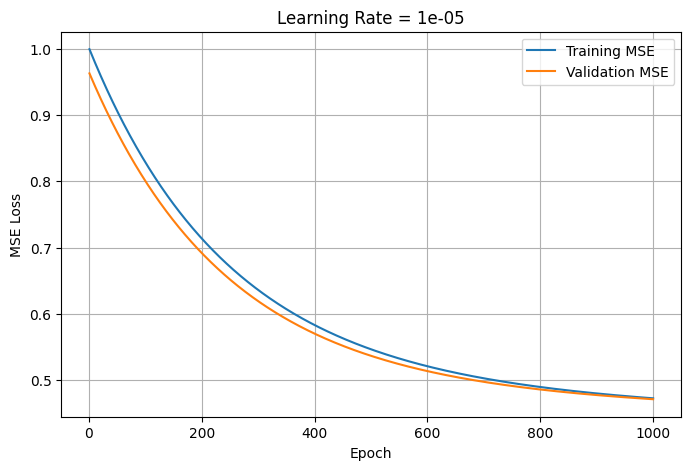

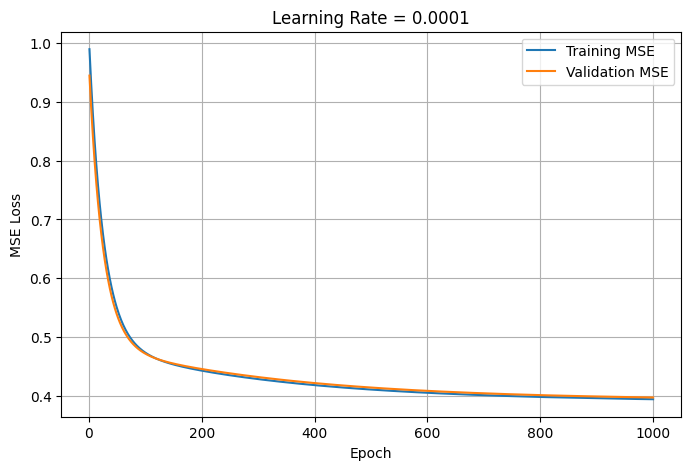

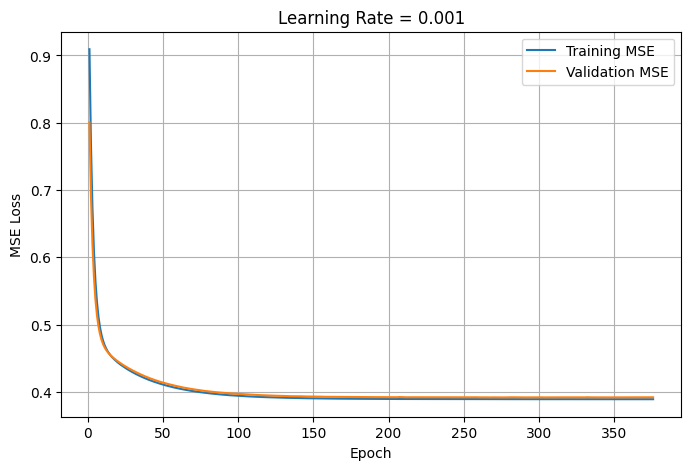

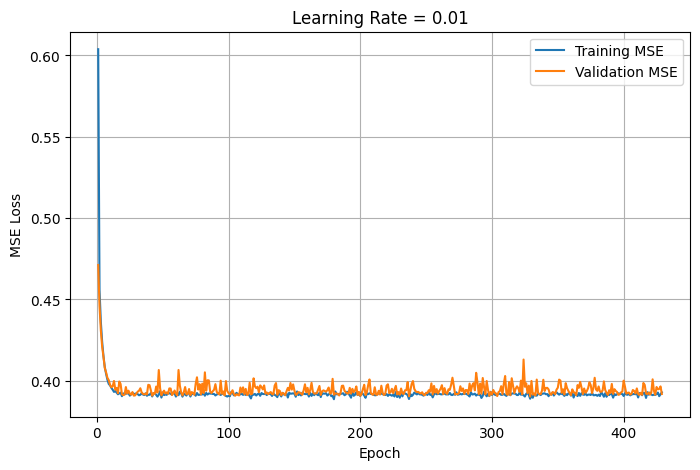

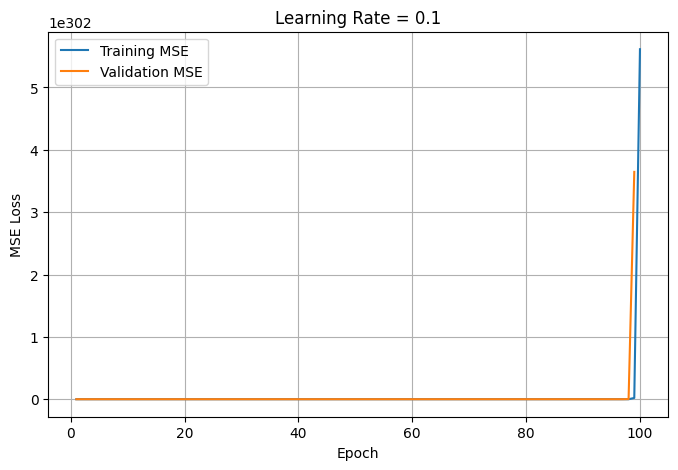

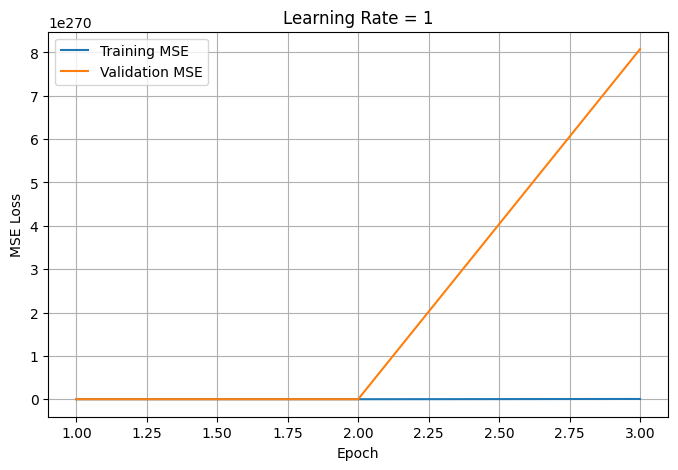

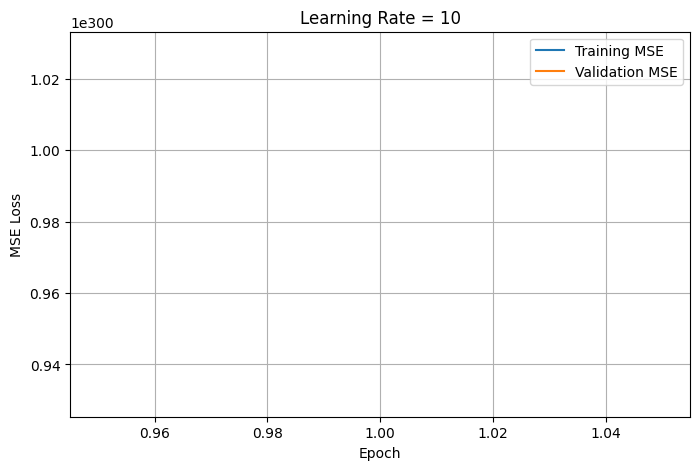

In [ ]:
import matplotlib.pyplot as plt

for lr in learning_rates:

    train_losses = results[lr]["train_losses"]
    val_losses = results[lr]["val_losses"]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(epochs, train_losses, label="Training MSE")
    plt.plot(epochs, val_losses, label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Learning Rate = {lr}")
    plt.legend()
    plt.grid(True)

    plt.show()

## ***Task 4: Effect of Batch Size***

In [ ]:
batch_sizes = [1,16,32,64,128,256,X_train.shape[0]]


batch_results = {}

for batch_size in batch_sizes:

    print("Training with batch size:", batch_size)

    best_weights, train_losses, val_losses, best_epoch = train_model(
        X_train,
        y_train.reshape(-1, 1),
        X_val,
        y_val.reshape(-1, 1),
        learning_rate=best_lr,
        batch_size=batch_size
    )

    batch_results[batch_size] = {
        "weights": best_weights,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch
    }

print("\n")
for batch_size in batch_sizes:

    val_losses = batch_results[batch_size]["val_losses"]

    lowest_val_mse = min(val_losses)
    best_epoch = batch_results[batch_size]["best_epoch"]

    print(
        "Batch size:",
        batch_size,
        "| Lowest validation MSE:",
        lowest_val_mse,
        "| Best epoch:",
        best_epoch
    )
print("\n")

best_batch_size = min(
    batch_sizes,
    key=lambda bs: min(batch_results[bs]["val_losses"])
)

print("Best batch size:", best_batch_size)



Training with batch size: 1


/tmp/ipykernel_3654/1181868508.py:53: RuntimeWarning: overflow encountered in scalar add
  total_loss += batch_mse * current_batch_size
/tmp/ipykernel_3654/1181868508.py:2: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipykernel_3654/1181868508.py:47: RuntimeWarning: overflow encountered in square
  batch_mse = np.mean(error ** 2)


Training with batch size: 16
Training with batch size: 32
Training with batch size: 64
Training with batch size: 128
Training with batch size: 256
Training with batch size: 12384


Batch size: 1 | Lowest validation MSE: 6611979.324653328 | Best epoch: 1
Batch size: 16 | Lowest validation MSE: 44.84838393235832 | Best epoch: 1
Batch size: 32 | Lowest validation MSE: 2.3468768451378725 | Best epoch: 1
Batch size: 64 | Lowest validation MSE: 0.3902331033254332 | Best epoch: 125
Batch size: 128 | Lowest validation MSE: 0.39062317653974693 | Best epoch: 29
Batch size: 256 | Lowest validation MSE: 0.3908634116131121 | Best epoch: 159
Batch size: 12384 | Lowest validation MSE: 0.39639576933149434 | Best epoch: 1000


Best batch size: 64


different plot for this different batch size

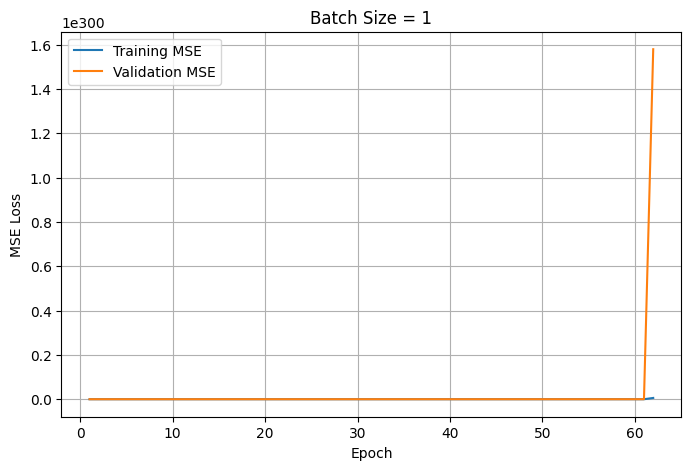

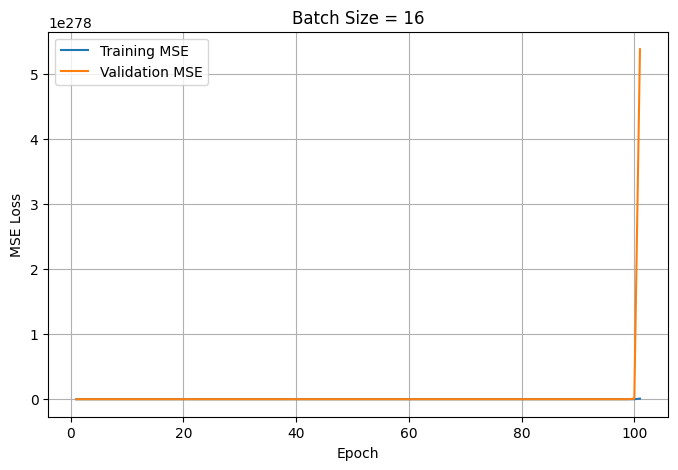

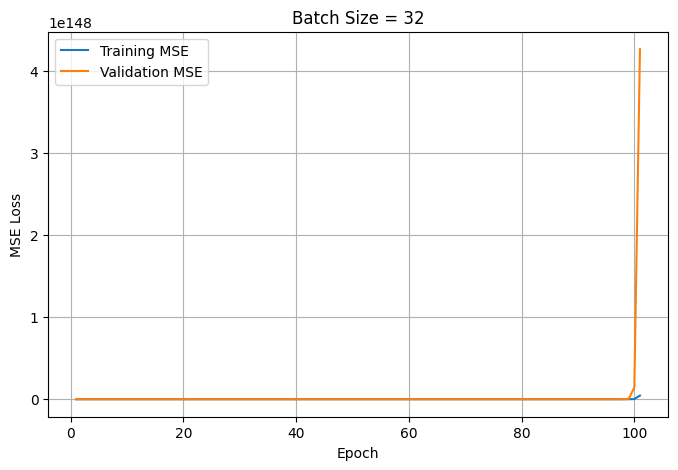

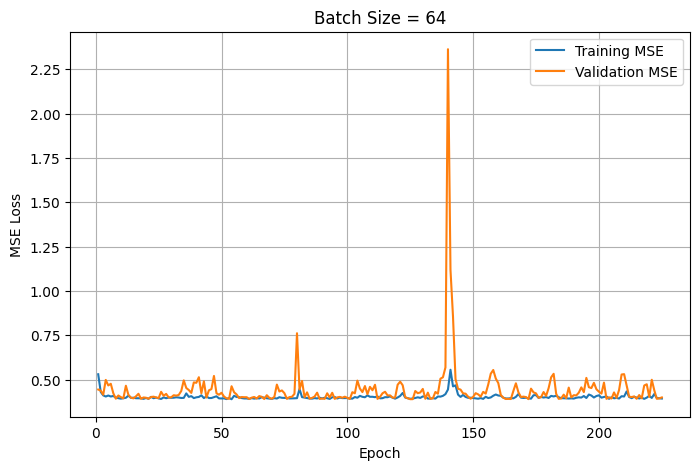

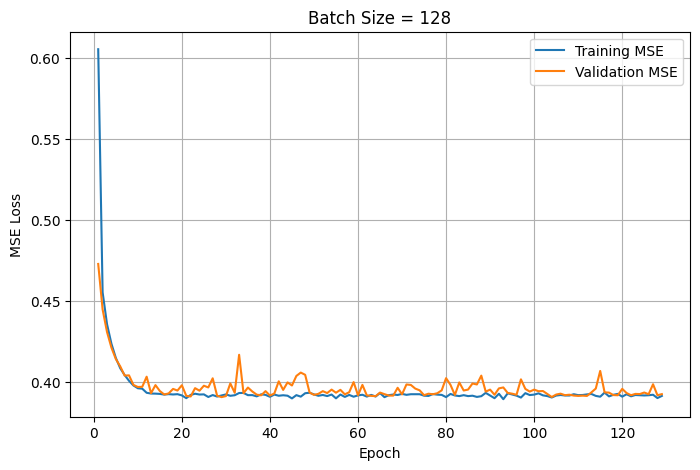

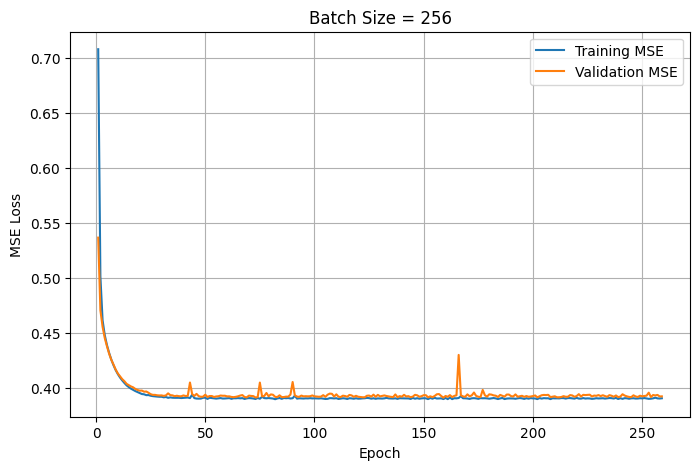

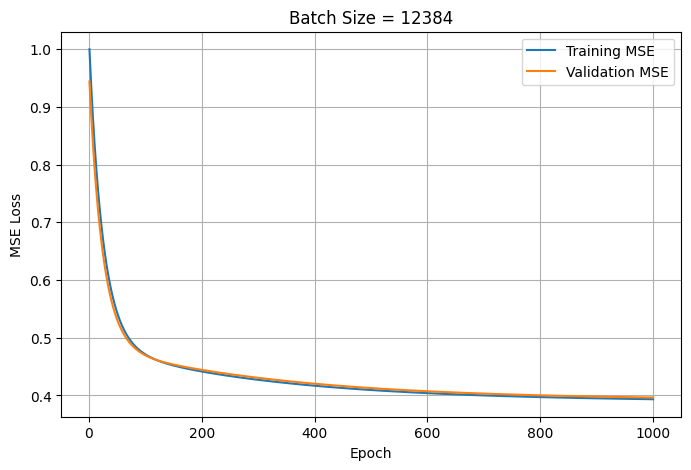

In [ ]:
for batch_size in batch_sizes:

    train_losses = batch_results[batch_size]["train_losses"]
    val_losses = batch_results[batch_size]["val_losses"]

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(8, 5))

    plt.plot(epochs, train_losses, label="Training MSE")
    plt.plot(epochs, val_losses, label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(f"Batch Size = {batch_size}")
    plt.legend()
    plt.grid(True)

    plt.show()

## ***Task 5: Inference on Test Set***

In [ ]:
final_weights = batch_results[best_batch_size]["weights"]

print("Best learning rate:", best_lr)
print("Best batch size:", best_batch_size)

#since we have done standardization and normalization
y_train_pred_std = X_train @ final_weights
y_val_pred_std = X_val @ final_weights
y_test_pred_std = X_test @ final_weights

#retrive it back to orignal form
y_train_pred = y_train_pred_std * y_std + y_mean
y_val_pred = y_val_pred_std * y_std + y_mean
y_test_pred = y_test_pred_std * y_std + y_mean

#original values that we have from dataset
y_train_original = y_train * y_std + y_mean
y_val_original = y_val * y_std + y_mean
y_test_original = y_test * y_std + y_mean

Best learning rate: 0.01
Best batch size: 64


function for calculating all performance metric

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def mape(y_true, y_pred):
    return 100 * np.mean(np.abs((y_true - y_pred) / y_true))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)


#calculating each for train,val,test dataset
train_rmse = rmse(y_train_original, y_train_pred.ravel())
train_mape = mape(y_train_original, y_train_pred.ravel())
train_mae = mae(y_train_original, y_train_pred.ravel())
train_r2 = r2_score(y_train_original, y_train_pred.ravel())


val_rmse = rmse(y_val_original, y_val_pred.ravel())
val_mape = mape(y_val_original, y_val_pred.ravel())
val_mae = mae(y_val_original, y_val_pred.ravel())
val_r2 = r2_score(y_val_original, y_val_pred.ravel())


test_rmse = rmse(y_test_original, y_test_pred.ravel())
test_mape = mape(y_test_original, y_test_pred.ravel())
test_mae = mae(y_test_original, y_test_pred.ravel())
test_r2 = r2_score(y_test_original, y_test_pred.ravel())

comparing and plotting part from the data obtained

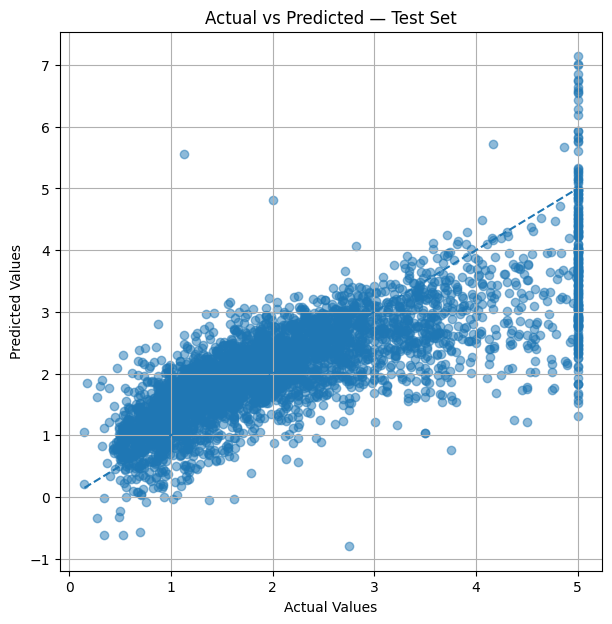

In [ ]:
#strucutre the data for plotting
import pandas as pd

results_table = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "RMSE": [train_rmse, val_rmse, test_rmse],
    "MAPE (%)": [train_mape, val_mape, test_mape],
    "MAE": [train_mae, val_mae, test_mae],
    "R²": [train_r2, val_r2, test_r2]
})

results_table

#actual plotting of data
plt.figure(figsize=(7, 7))

plt.scatter(y_test_original, y_test_pred.ravel(), alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted — Test Set")

# Reference line: Perfect prediction
min_value = min(y_test_original)
max_value = max(y_test_original)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.grid(True)
plt.show()

## ***Final Summary of all task***

In [45]:
print("FINAL SUMMARY")

print("\nDATASET")
print("Total samples:", x.shape[0])
print("Number of features:", x.shape[1])
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

print("\nBEST PARAMETERS")
print("Best learning rate:", best_lr)
print("Best batch size:", best_batch_size)

print("\nBEST MODEL")
print("Best validation MSE:",
      min(batch_results[best_batch_size]["val_losses"]))
print("Best epoch:",
      batch_results[best_batch_size]["best_epoch"])

print("\nFINAL TEST PERFORMANCE")
print("Test RMSE:", f"{test_rmse:.5f}")
print("Test MAPE:", f"{test_mape:.5f}")
print("Test MAE:", f"{test_mae:.5f}")
print("Test R2:", f"{test_r2:.5f}")

FINAL SUMMARY

DATASET
Total samples: 20640
Number of features: 8
Training samples: 12384
Validation samples: 4128
Test samples: 4128

BEST PARAMETERS
Best learning rate: 0.01
Best batch size: 64

BEST MODEL
Best validation MSE: 0.3902331033254332
Best epoch: 125

FINAL TEST PERFORMANCE
Test RMSE: 0.73087
Test MAPE: 31.22134
Test MAE: 0.53167
Test R2: 0.60307
